In [3]:
!pip install -q transformers datasets librosa evaluate jiwer accelerate
!pip install -q gradient-map 


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement gradient-map (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for gradient-map


In [4]:
from huggingface_hub import notebook_login

print("Please enter your Hugging Face write token.")
notebook_login()

Please enter your Hugging Face write token.


In [5]:
from datasets import load_dataset, Audio

# Load dataset
dataset_name = "hhoangphuoc/switchboard"
print(f"Loading {dataset_name}...")

# This dataset usually has 'train', 'validation', and 'test' splits
dataset = load_dataset(dataset_name)

# Inspect the dataset structure
print(dataset)

# Look at one sample
print("Sample:", dataset["train"][0])

Loading hhoangphuoc/switchboard...


Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/53 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['audio', 'sampling_rate', 'transcript'],
        num_rows: 185402
    })
    validation: Dataset({
        features: ['audio', 'sampling_rate', 'transcript'],
        num_rows: 20601
    })
    test: Dataset({
        features: ['audio', 'sampling_rate', 'transcript'],
        num_rows: 51501
    })
})
Sample: {'audio': <datasets.features._torchcodec.AudioDecoder object at 0x000001F9221F47D0>, 'sampling_rate': 16000, 'transcript': 'yeah'}


In [7]:
from transformers import WhisperProcessor

# Load Processor (Feature Extractor + Tokenizer)
model_id = "openai/whisper-small" # You can change to 'tiny' for faster training
processor = WhisperProcessor.from_pretrained(model_id, language="English", task="transcribe")

# Ensure audio is 16kHz (Whisper requirement)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

In [8]:
# --- STEP 1: Define the function (Same as before) ---
def prepare_dataset(batch):
    # 1. Extract audio data
    audio = batch["audio"]

    # 2. Compute log-Mel input features
    batch["input_features"] = processor.feature_extractor(
        [x["array"] for x in audio], # varied length audio
        sampling_rate=16000
    ).input_features

    # 3. Encode target text to label ids
    batch["labels"] = processor.tokenizer(batch["transcript"]).input_ids
    
    return batch

# --- STEP 2: The FIX (Use set_transform instead of map) ---
# This applies the function "on-the-fly" only when needed.
# It uses almost 0 RAM initially.

train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(200))

train_data.set_transform(prepare_dataset)
val_data.set_transform(prepare_dataset)

print("Transforms set. No memory explosion!")

Transforms set. No memory explosion!


In [9]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # input_features might be a list of arrays now due to set_transform
        # We ensure they are extracted correctly
        input_features = [
            {"input_features": feature["input_features"][0] if isinstance(feature["input_features"], list) else feature["input_features"]}
            for feature in features
        ]
        
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # mask padding with -100 so it's ignored in loss calculation
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # Remove BOS token if present (Whisper specific)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

# Initialize the collator
data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
print("Data Collator initialized successfully.")

Data Collator initialized successfully.


In [10]:
import evaluate

metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Replace -100 (padding) with the actual pad token id
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode the tokens back into text
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

In [11]:
from datasets import load_dataset, Audio

# 1. Reload dataset if it was lost during kernel restart
if 'dataset' not in locals():
    print("Reloading dataset (this might take a moment)...")
    dataset = load_dataset("hhoangphuoc/switchboard")
    dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

# 2. Define the memory-safe processing function
def prepare_dataset(batch):
    # Process audio only when needed
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(
        [x["array"] for x in audio], 
        sampling_rate=16000
    ).input_features
    
    # Process text
    batch["labels"] = processor.tokenizer(batch["transcript"]).input_ids
    return batch

# 3. Create the data splits (using .select to keep it small for testing)
train_data = dataset["train"].select(range(1000))
val_data = dataset["validation"].select(range(200))

# 4. Apply the transform
train_data.set_transform(prepare_dataset)
val_data.set_transform(prepare_dataset)

print("Success! train_data and val_data are defined.")

Success! train_data and val_data are defined.


In [12]:
from transformers import WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer

# 1. RELOAD the model to clear any previous "gradient checkpointing" settings
print("Reloading model to clear conflicting settings...")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

# 2. FORCE DISABLE Gradient Checkpointing (Critical for CPU)
model.config.gradient_checkpointing = False
model.config.use_cache = False 

# 3. Define Training Arguments (Strict CPU Mode)
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-switchboard-final",
    per_device_train_batch_size=2,       # Lower batch size for CPU safety
    gradient_accumulation_steps=8,       # Accumulate more to compensate
    learning_rate=1e-5,
    warmup_steps=20,
    max_steps=100,                       # Reduce steps for a quicker test run
    
    # --- CRITICAL CPU SETTINGS ---
    gradient_checkpointing=False,        # MUST BE FALSE
    fp16=False,                          # MUST BE FALSE (CPU doesn't support fp16 well)
    dataloader_pin_memory=False,         # Fixes the "pin_memory" warning
    # -----------------------------
    
    eval_strategy="steps",
    per_device_eval_batch_size=2,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=50,
    eval_steps=50,
    logging_steps=10,
    push_to_hub=False,
    report_to=["none"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    remove_unused_columns=False,
)

# 4. Initialize Trainer
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

print("Starting training (CPU Mode)... this will be slower but stable.")
trainer.train()

Reloading model to clear conflicting settings...
Starting training (CPU Mode)... this will be slower but stable.


You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Wer
50,1.581400,1.586625,0.193045
100,1.428000,1.395880,0.105749


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
C:\Users\N.Thaheera\AppData\Roaming\Python\Python313\site-packages\transformers\modeling_utils.py:3922: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27,

TrainOutput(global_step=100, training_loss=2.3787977504730224, metrics={'train_runtime': 22682.7219, 'train_samples_per_second': 0.071, 'train_steps_per_second': 0.004, 'total_flos': 4.5942795730944e+17, 'train_loss': 2.3787977504730224, 'epoch': 1.592})

In [13]:
save_directory = "./final_switchboard_model"
model.save_pretrained(save_directory)
processor.save_pretrained(save_directory)

print(f"Model saved locally to {save_directory}")

Model saved locally to ./final_switchboard_model


In [14]:
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor

# 1. Load your just-saved model (or use the current one in memory)
device = "cpu" # Since you are on CPU
model = WhisperForConditionalGeneration.from_pretrained(save_directory).to(device)
processor = WhisperProcessor.from_pretrained(save_directory)

# 2. Pick a random sample from the test dataset
# (Ensure you have the test data loaded)
test_sample = dataset["test"][5] # Change index to see different samples

print(f"Reference Text: {test_sample['transcript']}")

# 3. Process the audio
audio_input = test_sample["audio"]["array"]
inputs = processor(audio_input, sampling_rate=16000, return_tensors="pt").input_features.to(device)

# 4. Generate Transcription
with torch.no_grad():
    generated_ids = model.generate(inputs)

# 5. Decode and Print
transcription = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("-" * 30)
print(f"Model Prediction: {transcription}")
print("-" * 30)

if test_sample['transcript'].lower() in transcription.lower():
    print("✅ Great match!")
else:
    print("⚠️ Some differences found.")

Reference Text: uh oh well now i i guess i just pick out and read out of both of them what interests me there is an article about


`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. If this is not desired, please set these values explicitly.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProce

------------------------------
Model Prediction: yeah um oh well now i i guess i just pick out and read out of both of them what interest me there is an article about
------------------------------
⚠️ Some differences found.


Loading openai/whisper-small...


Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Scanning 100 samples for ANY errors...
..10..20..30..40..50..60..70..80..90..100
Scan complete.
Found 55 total character errors.


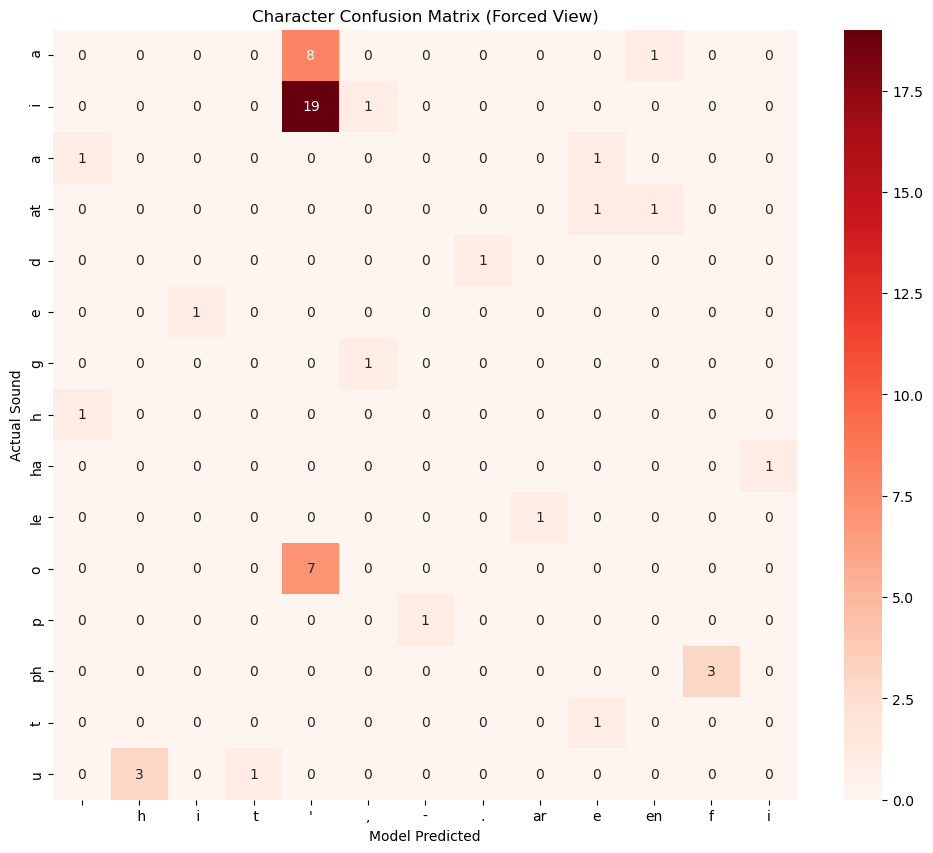

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import difflib
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from datasets import load_dataset, Audio

# 1. Load Resources
device = "cpu"
model_id = "openai/whisper-small" # Using the base model since local is gone
print(f"Loading {model_id}...")

processor = WhisperProcessor.from_pretrained(model_id)
model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device)

dataset = load_dataset("hhoangphuoc/switchboard", split="test", streaming=True)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

# 2. Analysis Function (With "Low Error" sensitivity)
def get_all_confusions(dataset, num_samples=100):
    confusions = []
    print(f"Scanning {num_samples} samples for ANY errors...")
    
    data_iter = iter(dataset.take(num_samples))
    
    for i, item in enumerate(data_iter):
        # Progress indicator every 10 samples
        if (i+1) % 10 == 0: print(f"..{i+1}", end="", flush=True)

        audio_array = item["audio"]["array"]
        inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)
        attention_mask = torch.ones(input_features.shape, device=device)

        with torch.no_grad():
            predicted_ids = model.generate(
                input_features, 
                language="en",
                attention_mask=attention_mask 
            )
        
        reference = item["transcript"].lower()
        prediction = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].lower()
        
        # Capture ALL substitutions
        matcher = difflib.SequenceMatcher(None, reference, prediction)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag == 'replace':
                ref_segment = reference[i1:i2]
                pred_segment = prediction[j1:j2]
                # Allow slightly larger swaps (up to 2 chars) to catch more data
                if len(ref_segment) <= 2 and len(pred_segment) <= 2:
                    confusions.append((ref_segment, pred_segment))
    print("\nScan complete.")
    return confusions

# 3. Plotting Logic (Force Plot)
errors = get_all_confusions(dataset, num_samples=100)

if not errors:
    print("✅ Amazing! The model made ZERO character errors in 100 samples.")
else:
    df_errors = pd.DataFrame(errors, columns=["Actual", "Predicted"])
    
    # Simple count
    print(f"Found {len(df_errors)} total character errors.")
    
    # If we have too many types of errors, take top 20. If few, take all.
    if len(df_errors["Actual"].unique()) > 20:
        top_chars = df_errors["Actual"].value_counts().head(20).index
        df_plot = df_errors[df_errors["Actual"].isin(top_chars) & df_errors["Predicted"].isin(top_chars)]
    else:
        df_plot = df_errors # Plot everything

    plt.figure(figsize=(12, 10))
    confusion_matrix = pd.crosstab(df_plot["Actual"], df_plot["Predicted"])
    sns.heatmap(confusion_matrix, annot=True, cmap="Reds", fmt='d')
    plt.title("Character Confusion Matrix (Forced View)")
    plt.ylabel("Actual Sound")
    plt.xlabel("Model Predicted")
    plt.show()

Loading data for Decision Tree...


Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Extracting features (this converts audio to numbers)...
Data ready: (200, 13) features extracted.
------------------------------
Decision Tree Accuracy: 80.00%
------------------------------


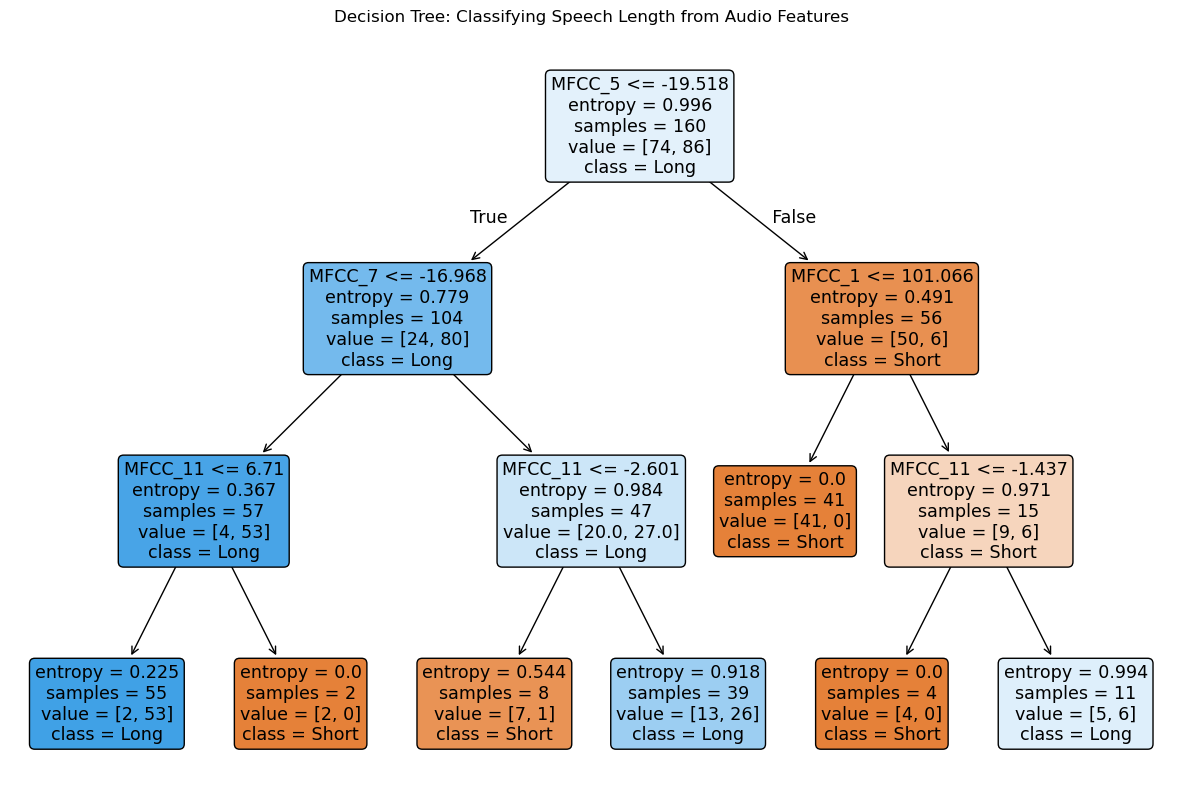

In [6]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from datasets import load_dataset

# 1. Load a small subset of data (processed in memory for sklearn)
print("Loading data for Decision Tree...")
dataset = load_dataset("hhoangphuoc/switchboard", split="train", streaming=True)

X = []  # Features (Numbers)
y = []  # Labels (0 = Short, 1 = Long)

# We will analyze 200 samples
iterator = iter(dataset.take(200))

print("Extracting features (this converts audio to numbers)...")
for i, item in enumerate(iterator):
    # --- Feature Extraction ---
    audio_array = np.array(item["audio"]["array"])
    sampling_rate = 16000
    
    # 1. Extract MFCCs (The standard "fingerprint" of audio)
    # We take the mean to get a single vector of numbers per file
    mfcc = librosa.feature.mfcc(y=audio_array, sr=sampling_rate, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0) # Shape: (13,)
    
    X.append(mfcc_mean)
    
    # --- Create Labels ---
    # If transcript is longer than 20 characters, we call it "Long Speech" (1)
    # Otherwise it's "Short Speech/Backchannel" (0)
    text_len = len(item["transcript"])
    label = 1 if text_len > 20 else 0
    y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Data ready: {X.shape} features extracted.")

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Decision Tree
# max_depth=3 keeps the tree simple and visualize-able
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("-" * 30)
print(f"Decision Tree Accuracy: {acc*100:.2f}%")
print("-" * 30)

# 5. Visualize the Tree
plt.figure(figsize=(15, 10))
plot_tree(clf, 
          filled=True, 
          feature_names=[f"MFCC_{i}" for i in range(13)],
          class_names=["Short", "Long"],
          rounded=True)
plt.title("Decision Tree: Classifying Speech Length from Audio Features")
plt.show()